DFS Traversal: ['A', 'B', 'D', 'E', 'H', 'C', 'F', 'G']


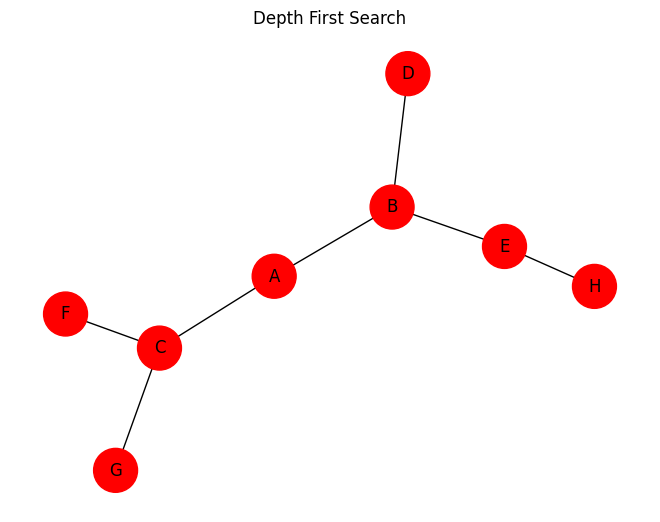

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt


G = nx.Graph()

edges = [
    ('A', 'B'), ('A', 'C'),
    ('B', 'D'), ('B', 'E'),
    ('C', 'F'), ('C', 'G'),
    ('E', 'H')
]

G.add_edges_from(edges)


start = 'A'
visited = []
stack = [start]

while stack:
    node = stack.pop()
    if node not in visited:
        visited.append(node)
        # Add unvisited neighbors to stack (reversed for alphabetical order)
        for neighbour in sorted(G.neighbors(node), reverse=True):
            if neighbour not in visited:
                stack.append(neighbour)

print("DFS Traversal:", visited)


pos = nx.spring_layout(G, seed=42)

node_colors = [
    'red' if node in visited else 'lightblue'
    for node in G.nodes()
]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1000,
    node_color=node_colors,
    font_size=12
)

plt.title("Depth First Search")
plt.show()

DFS Traversal Order:
['A', 'B', 'D', 'E', 'H', 'C', 'F', 'G']


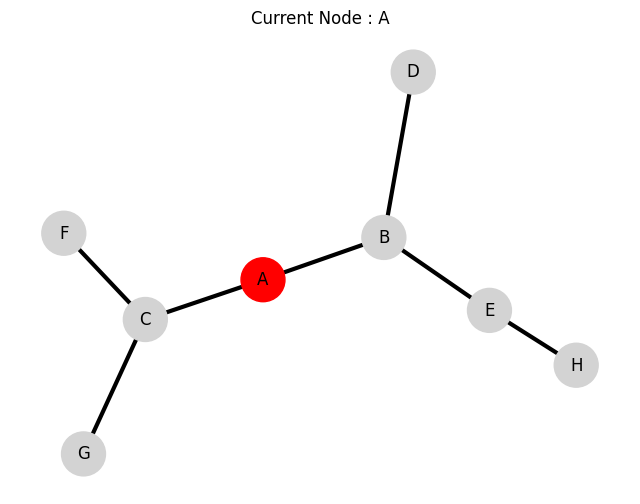

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


G = nx.Graph()

edges = [
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F'),
    ('C', 'G'),
    ('E', 'H')
]

G.add_edges_from(edges)


visited = []
parent = {}
stack = ['A']

while stack:
    node = stack.pop()
    if node not in visited:
        visited.append(node)
        for neighbour in sorted(G.neighbors(node), reverse=True):
            if neighbour not in visited:
                if neighbour not in parent:
                    parent[neighbour] = node
                stack.append(neighbour)

print("DFS Traversal Order:")
print(visited)


pos = nx.spring_layout(G, seed=5)
fig, ax = plt.subplots(figsize=(8, 6))

def update(frame):
    ax.clear()
    visited_now = visited[:frame + 1]

    node_colors = [
        'red' if n in visited_now else 'lightgray'
        for n in G.nodes()
    ]

    edge_colors = []
    for u, v in G.edges():
        if ((v in parent and parent[v] == u and v in visited_now) or
            (u in parent and parent[u] == v and u in visited_now)):
            edge_colors.append('green')
        else:
            edge_colors.append('black')

    nx.draw(
        G,
        pos,
        ax=ax,
        with_labels=True,
        node_color=node_colors,
        edge_color=edge_colors,
        node_size=1000,
        width=3
    )

    ax.set_title(f"Current Node : {visited[frame]}")


ani = FuncAnimation(
    fig,
    update,
    frames=len(visited),
    interval=1200,
    repeat=False
)


HTML(ani.to_jshtml())